## INTRODUCTION

Mwaura Ngugi-677652

Dataset - Online retail data II UCI

Dataset source - Kaggle 
 
Number of rows and columns - (1017177, 38)

Research Questions:
1. What are the revenue trends?
2. Which are the top selling products
3. How do the customers behave when purchasing various products
4. How do Sales compare in respect to other countries

Cleaning steps:

1. Remove all rows with missing values
2. Checking and removing duplicates
3. Checking Data types
4. Creating a revenue column(TotalPrice)
5. Converting the Date column.


In [45]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Administrator\Desktop\data\raw_dataset.csv.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,...,DescLength,WordCount,HasSet,HasPack,IsUK,CountryCount,Region,YearMonth,DayName,WeekendOrder
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,...,35,6,0,0,1,981330,Europe,2009-12,Tuesday,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,18,3,0,0,1,981330,Europe,2009-12,Tuesday,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,20,3,0,0,1,981330,Europe,2009-12,Tuesday,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,...,28,5,0,0,1,981330,Europe,2009-12,Tuesday,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,...,30,4,0,0,1,981330,Europe,2009-12,Tuesday,0


In [46]:
#checking for missing values
df.isnull().sum()

Invoice                   0
StockCode                 0
Description            4382
Quantity                  0
InvoiceDate               0
Price                     0
Customer ID               0
Country                   0
Year                      0
Month                     0
Day                       0
Hour                      0
Minute                    0
DayOfWeek                 0
WeekOfYear                0
IsWeekend                 0
TotalPrice                0
LogPrice                  5
LogQuantity           14053
PriceCategory           250
QuantityCategory        172
HighValueOrder            0
IsReturn                  0
AvgPricePerItem           0
CustomerID_String         0
IsGuest                   0
CustomerOrderCount        0
ReturningCustomer         0
DescLength                0
WordCount                 0
HasSet                    0
HasPack                   0
IsUK                      0
CountryCount              0
Region                    0
YearMonth           

In [ ]:
#Removing rows with missing values
df=df.dropna()
df.isnull().sum()

Invoice               0
StockCode             0
Description           0
Quantity              0
InvoiceDate           0
Price                 0
Customer ID           0
Country               0
Year                  0
Month                 0
Day                   0
Hour                  0
Minute                0
DayOfWeek             0
WeekOfYear            0
IsWeekend             0
TotalPrice            0
LogPrice              0
LogQuantity           0
PriceCategory         0
QuantityCategory      0
HighValueOrder        0
IsReturn              0
AvgPricePerItem       0
CustomerID_String     0
IsGuest               0
CustomerOrderCount    0
ReturningCustomer     0
DescLength            0
WordCount             0
HasSet                0
HasPack               0
IsUK                  0
CountryCount          0
Region                0
YearMonth             0
DayName               0
WeekendOrder          0
dtype: int64

In [48]:
#checking for duplicates
df.duplicated().sum()


np.int64(33994)

In [49]:
#Removing duplicated values
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [50]:
#Checking number rows after cleaning
df.shape


(1017177, 38)

In [51]:
#check data types
df.dtypes


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate            object
Price                 float64
Customer ID           float64
Country                object
Year                    int64
Month                   int64
Day                     int64
Hour                    int64
Minute                  int64
DayOfWeek               int64
WeekOfYear              int64
IsWeekend               int64
TotalPrice            float64
LogPrice              float64
LogQuantity           float64
PriceCategory          object
QuantityCategory       object
HighValueOrder          int64
IsReturn                int64
AvgPricePerItem       float64
CustomerID_String     float64
IsGuest                 int64
CustomerOrderCount      int64
ReturningCustomer       int64
DescLength              int64
WordCount               int64
HasSet                  int64
HasPack                 int64
IsUK                    int64
CountryCou

In [ ]:
#correct data types
import numpy  as np
df["Invoice"]=df["Invoice"].astype(str)
df["StockCode"]=df["StockCode"].astype(str)
df["Description"]=df["Description"].astype(str)
df["Quantity"] = df["Quantity"].astype(int)
df["Price"] = df["Price"].astype(float)
df["Customer ID"] = df["Customer ID"].astype(str)
df=df[df["Quantity"]>0]
df["Country"] = df["Country"].astype(str)

df['TotalPrice'] = df['Quantity'] * df['Price']# Revenue column created
df['LogPrice'] = np.log1p(df['Price'])
df['LogQuantity'] = np.log1p(df['Quantity'])

df['PriceCategory'] = pd.cut(df['Price'],
                            bins=[-1, 2, 5, 1000],
                            labels=['Low', 'Medium', 'High'])

df['QuantityCategory'] = pd.cut(df['Quantity'],
                               bins=[-1000, 1, 10, 10000],
                               labels=['Small', 'Medium', 'Bulk'])

df['HighValueOrder'] = (df['TotalPrice'] > 100).astype(int)
df['IsReturn'] = (df['Quantity'] < 0).astype(int)
df['AvgPricePerItem'] = df['Price']


#4. CUSTOMER FEATURES (4 columns)

df['CustomerID_String'] = df['Customer ID'].astype(str)
df['IsGuest'] = (df['Customer ID'] == 0).astype(int)

df['CustomerOrderCount'] = df.groupby('Customer ID')['Invoice'].transform('count')
df['ReturningCustomer'] = (df['CustomerOrderCount'] > 1).astype(int)


# 5. TEXT FEATURES (4 columns)


df['DescLength'] = df['Description'].apply(len)
df['WordCount'] = df['Description'].apply(lambda x: len(x.split()))
df['HasSet'] = df['Description'].str.contains("SET", case=False).astype(int)
df['HasPack'] = df['Description'].str.contains("PACK", case=False).astype(int)


# 6. COUNTRY FEATURES (3 columns)

df['IsUK'] = (df['Country'] == 'United Kingdom').astype(int)

df['CountryCount'] = df.groupby('Country')['Invoice'].transform('count')

df['Region'] = df['Country'].apply(lambda x: 'Europe' if x == 'United Kingdom' else 'Other')


# 7. COMBINED FEATURES (3 columns)
df['YearMonth'] = df['Year'].astype(str) + "-" + df['Month'].astype(str)
df["DayName"]=df["InvoiceDate"].dt.day_name()
df['WeekendOrder'] = ((df['IsWeekend'] == 1) & (df['TotalPrice'] > 50)).astype(int)

df.dtypes



Invoice                       object
StockCode                     object
Description                   object
Quantity                       int64
InvoiceDate           datetime64[ns]
Price                        float64
Customer ID                   object
Country                       object
Year                           int64
Month                          int64
Day                            int64
Hour                           int64
Minute                         int64
DayOfWeek                      int64
WeekOfYear                     int64
IsWeekend                      int64
TotalPrice                   float64
LogPrice                     float64
LogQuantity                  float64
PriceCategory               category
QuantityCategory            category
HighValueOrder                 int64
IsReturn                       int64
AvgPricePerItem              float64
CustomerID_String             object
IsGuest                        int64
CustomerOrderCount             int64
R

In [52]:
#Convert Date Column
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])


We convert the date column to allow Time based analysis which is grouping by month or year since the InvoivceDate is in String format

In [54]:

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Minute'] = df['InvoiceDate'].dt.minute
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['WeekOfYear'] = df['InvoiceDate'].dt.isocalendar().week
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

In [ ]:
#Save cleaned dataset
df.to_csv("data/clean_online_retail.csv",index=False)


# SUMMARY STATISTICS

In [ ]:

import pandas as pd
clean=pd.read_csv(r"C:\Users\Administrator\Desktop\data\clean_online_retail.csv")


#RELEVANT COLUMNS
columns = ['Quantity', 'Price', 'TotalPrice']
data = clean[columns]

print("Summary Statistics:")
summary = data.describe()
display(summary)

print("\nAdditional Statistics:")

# Mean
mean_values = data.mean()

# Median
median_values = data.median()

# Standard Deviation
std_values = data.std()

# Min & Max
min_values = data.min()
max_values = data.max()

print("\nMean:")
display(mean_values)

print("\nMedian:")
display(median_values)

print("\nStandard Deviation:")
display(std_values)

print("\nMinimum Values:")
display(min_values)

print("\nMaximum Values:")
display(max_values)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19992\904005619.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  clean=pd.read_csv(r"C:\Users\Administrator\Desktop\data\clean_online_retail.csv")


Summary Statistics:


,Quantity,Price,TotalPrice
count,1.008773e+06,1.008773e+06,1.008773e+06
mean,1.093032e+01,3.720053e+00,1.969698e+01
std,5.989235e+01,1.254891e+01,7.661696e+01
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,1.000000e+04,9.880000e+02,3.897000e+04



Additional Statistics:

Mean:


Quantity      10.930321
Price          3.720053
TotalPrice    19.696978
dtype: float64

...

Quantity      59.892355
Price         12.548914
TotalPrice    76.616957
dtype: float64


Minimum Values:


Quantity      1.0
Price         0.0
TotalPrice    0.0
dtype: float64


Maximum Values:


Quantity      10000.0
Price           988.0
TotalPrice    38970.0
dtype: float64

In [56]:
#GROUPING AND AGGREGATION
clean["InvoiceDate"]=pd.to_datetime(clean["InvoiceDate"])
clean.set_index("InvoiceDate").groupby(pd.Grouper(freq='M'))["TotalPrice"].sum()#Groups data by month and sums sales


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19992\1908877210.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  clean.set_index("InvoiceDate").groupby(pd.Grouper(freq='M'))["TotalPrice"].sum()#Groups data by month and sums sales


InvoiceDate
2009-12-31     821270.930
2010-01-31     634776.892
2010-02-28     548454.446
2010-03-31     777704.441
2010-04-30     660486.362
2010-05-31     654151.740
2010-06-30     714006.210
2010-07-31     645199.770
2010-08-31     687432.080
2010-09-30     886385.261
2010-10-31    1117182.450
2010-11-30    1456151.142
2010-12-31     806613.000
2011-01-31     612628.010
2011-02-28     522545.560
2011-03-31     710257.160
2011-04-30     528275.391
2011-05-31     758669.900
2011-06-30     757413.890
2011-07-31     712196.001
2011-08-31     737294.480
2011-09-30    1049086.892
2011-10-31    1130681.970
2011-11-30    1485969.680
2011-12-31     454945.520
Freq: ME, Name: TotalPrice, dtype: float64

In [57]:
clean.groupby("Country").agg({"Quantity":"sum","Price":"sum","TotalPrice":"sum"})#Sales of each country

,Quantity,Price,TotalPrice
Country,,,
Australia,104067,6427.410,1.692835e+05
Austria,11578,3947.710,2.361301e+04
Bahrain,1339,431.430,3.109790e+03
Belgium,34777,11455.370,6.387917e+04
Bermuda,2798,84.700,1.253140e+03
Brazil,545,256.310,1.411870e+03
Canada,3657,1058.090,4.883040e+03
Channel Islands,21396,7113.530,4.462333e+04
Cyprus,10950,5821.440,2.484995e+04


In [58]:
df.groupby("Customer ID").agg({"Quantity":"sum","TotalPrice":"sum"})#High value customer

,Quantity,TotalPrice
Customer ID,,
0.0,735595,2870655.21
12346.0,70,372.86
12347.0,2967,4921.53
12348.0,2714,2019.40
12349.0,1624,4428.69
...,...,...
18283.0,1679,2664.90
18284.0,494,461.68
18285.0,145,427.00


In [59]:
clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)#Showing top selling products


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106250
WHITE HANGING HEART T-LIGHT HOLDER     94663
ASSORTED COLOUR BIRD ORNAMENT          80090
JUMBO BAG RED RETROSPOT                77705
BROCADE RING PURSE                     70379
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48597
PACK OF 72 RETROSPOT CAKE CASES        48156
PACK OF 72 RETRO SPOT CAKE CASES       46728
Name: Quantity, dtype: int64

# VISUALIZATIONS

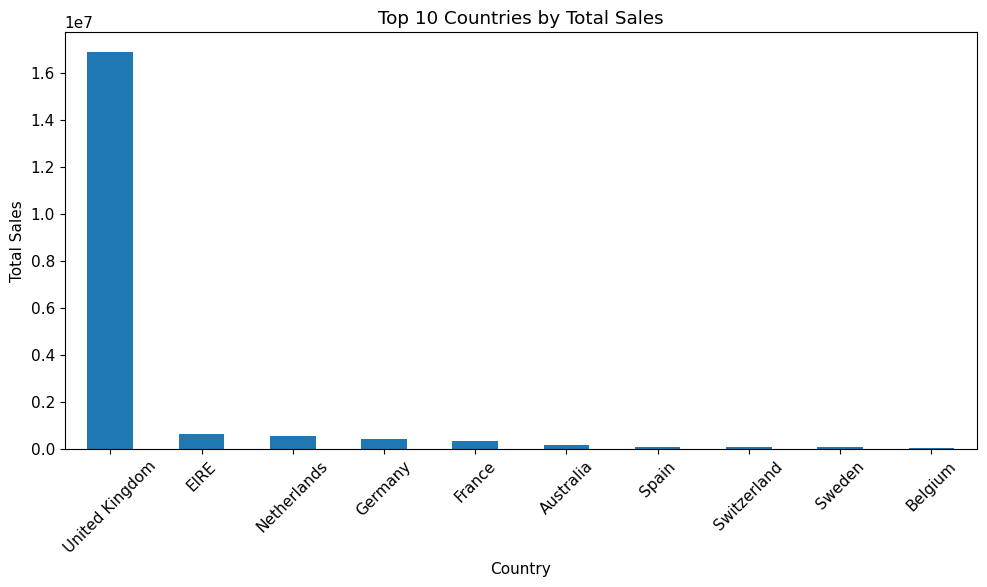

In [60]:
#BAR CHART
import matplotlib.pyplot as plt
import os

#create folder
os.makedirs("visuals",exist_ok=True)
plt.rcParams["figure.figsize"]=(10,6)
plt.rcParams["font.size"]=11

country_sales = clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
country_sales.plot(kind='bar')

plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('visuals/country_sales.png')
plt.show()
#INTERPRETATION:
#The quantity purchased is highest in The United Kingdom this shows that there is 
#high demand in The United Kingdom as compared to other countries



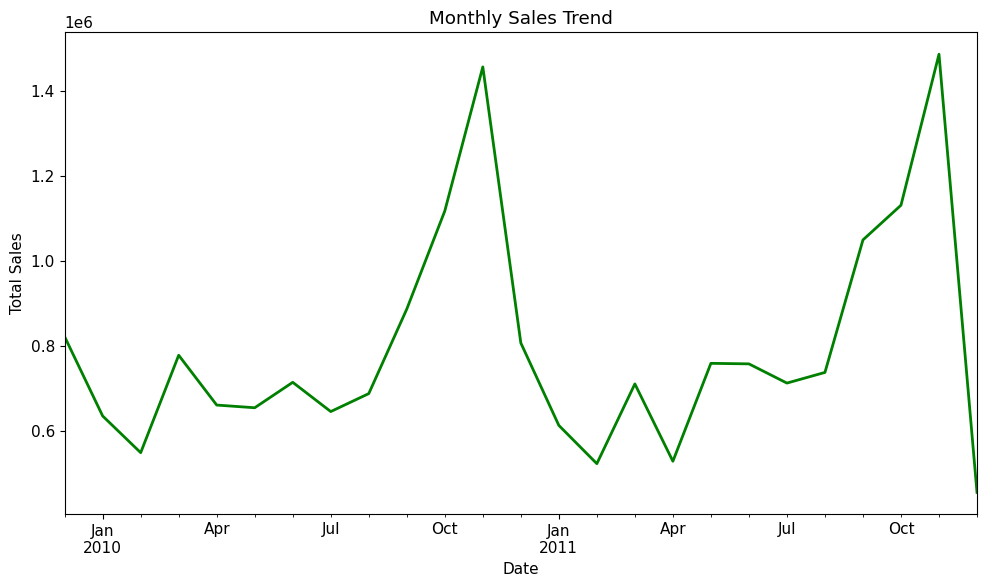

In [61]:
#LINE CHART(Time based)
monthly_sales = df.set_index("InvoiceDate").groupby(pd.Grouper(freq='ME'))["TotalPrice"].sum()

plt.figure()
monthly_sales.plot(color="green",linewidth=2)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.savefig('visuals/monthly_sales.png')
plt.show()

#INTERPRETATION:
#The line plot shows that most of the quantity purchased was done in December since there is peak in sales 
#around December which suggests that
#demand is seasonal.



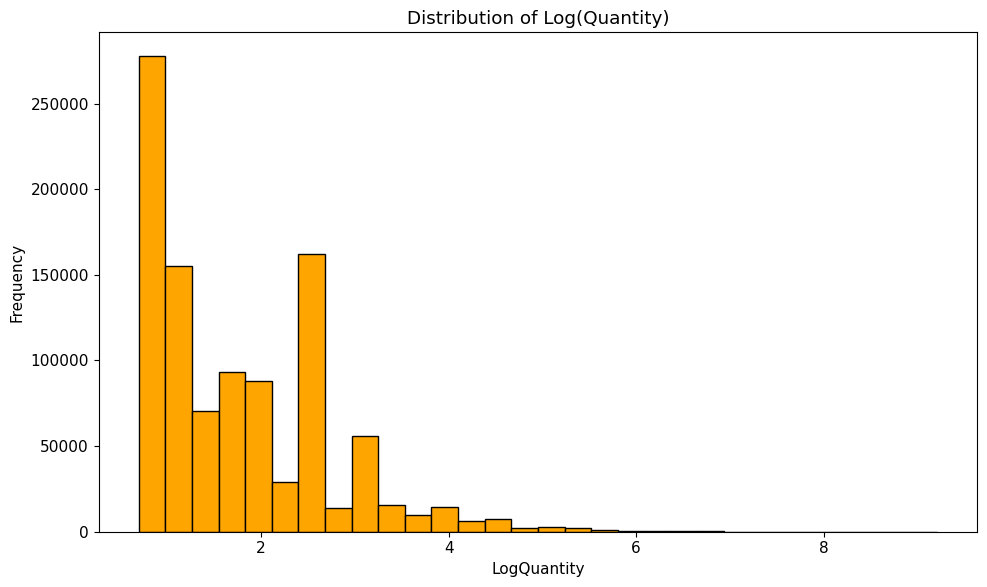

In [62]:
#DISTRIBUTION PLOT
plt.figure()
clean['LogQuantity'].plot(kind='hist', bins=30,color="orange",edgecolor="black")

plt.title('Distribution of Log(Quantity)')
plt.xlabel('LogQuantity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('visuals/quantity_distribution.png')
plt.show()

#INTERPRETATION:
#The original quantity was highly skewed with many outliers so applying a logarithmic transformation compresses the 
#scale and reveals underlying patterns more clearly, making the data more suitable for analysis.
#Therefore this indicates that most purchases cluster around moderate values, indicating that customers typically 
# purchase in small to medium quantities, while large bulk purchases are less.


In [ ]:
#COMPARATIVE BAR GRAPH
avg_price = clean.groupby('Country')['Price'].mean().sort_values(ascending=False).head(10)

plt.figure()
avg_price.plot(kind='bar',color="indianred")

plt.title('Average Price by Country (Top 10)')
plt.xlabel('Country')
plt.ylabel('Average Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('visuals/avg_price_country.png')
plt.show()

#INTERPRETATION:
#Some countries have higher average prices, which may indicate premium products or pricing differences.

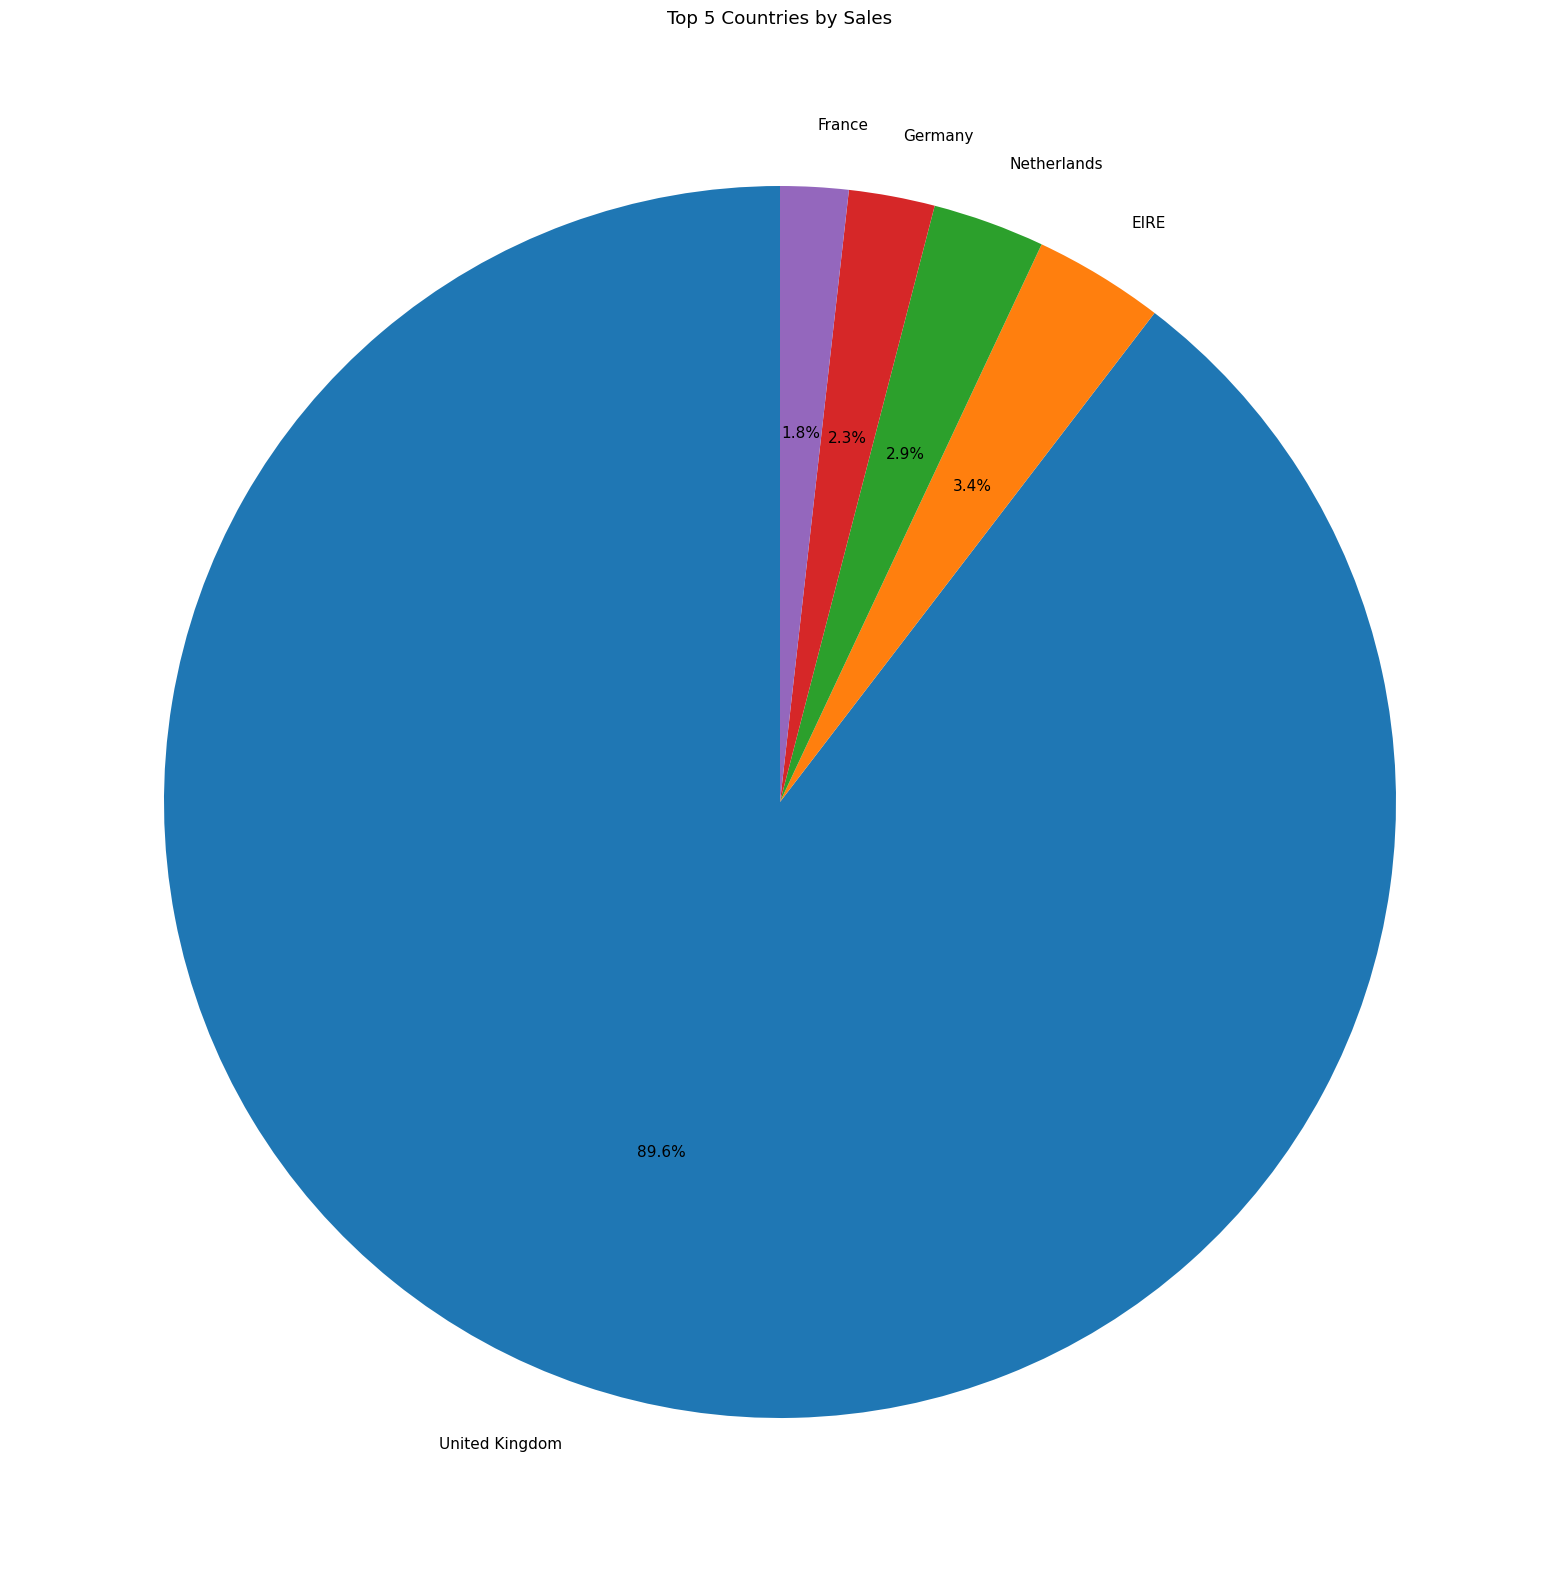

In [63]:
#PIE CHART
sales_by_country = clean.groupby('Country')['TotalPrice'].sum()
import matplotlib.pyplot as plt

top5 = sales_by_country.sort_values(ascending=False).head(5)

plt.figure(figsize=(20,20))
top5.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Top 5 Countries by Sales')
plt.ylabel('')
plt.show()

#INTERPRETATION
#The pie chart shows the propotion of total Sales contributed by each country. It is evident that a few countries 
#dominate Sales with the top contributers being the UK which accounts the largest share which suggests that the 
#business relies heavily on specific markets.

In [ ]:
#RANKING(Top to bottom)
top_customers=df.groupby("Customer ID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
top_products=df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
print("top customers:\n",top_customers)
print("top products:\n",top_products)




# INTERPRETATION(CUSTOMERS)
The ranking of customers based on the total spending reveals a significant concentration of revenue from a small group 
 of high-value customers.

# INTERPRETATION(PRODUCTS)
The product shows that certain products dominate total sales volume, indicating strong customer preferences for those products.

In [ ]:
#SEGEMNTATION
df["CustomerSegment"]=pd.qcut(df["TotalPrice"],q=3,labels=["Low spender","Medium spender","High Spender"])
print(df[["CustomerSegment","TotalPrice"]].head(10))




# INTERPRETATION
From the output, the displayed observations show that the customers fall within higher spender category, indicating that these customers have relatively higher
transaction values compared to others in the dataset.

In [ ]:
#COMPARISON
df.groupby("IsWeekend")["TotalPrice"].mean()
print(df.groupby("IsWeekend")["TotalPrice"].mean())




# INTERPRETATION
The analysis compares the average total sales between weekdays and weekends.
The average transaction value is higher on weekdays compared to weekends, this suggests that customers tend to purchase 
on the weekdays and in the weekends the customers tend to purchase less as compared to weekdays because as we can see the purchases are in small quantities.

# KEY INSIGHTS
1. A few products consistently rank at the top, indicating high customer demand for specific items
2. The business heavily depends on a few high valued customers
3. The business receives most of its revenue from the UK indicating the business dominates the UK market more than the rest of the regions which indicates sales are not evenly distributed
4. Revenue peaks around November and followed by a drop in December which suggests high activity before holidays.
5. The average transaction value is higher on weekdays than on the weekends this shows that customers tend to purchase more on the weekdays than on the weekends since small quantities are purchased on the weekends

# RECOMMENDATIONS
1. The business should strengthen its presence in high performing markets such as the UK while also exploring strategies to expand in underperforming regions to diversify revenue sources to reduce risk.
2. The presence of extremely high-value customers suggests an opportunity to focus on customer retention and relationship management. These customers are critical to revenue generation and should be prioritized through targeted strategies.
3. The consistent increase in revenue toward the end of each year highlights the importance of seasonal demand in driving sales. The business appears to rely heavily on peak periods, particularly around November, for revenue growth.
